<a href="https://colab.research.google.com/github/FuadAzaroglu/AI_Master/blob/AI_Assignments/Activity_4_Supervised_Learning_(Decision_Tree_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yellowbrick seaborn


In [2]:
import pandas as pd
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [5]:
# Select simple, interpretable attributes
features = ["Pclass", "Sex", "Age", "Fare"]
df = df[features + ["Survived"]]

# Handle missing values
df["Age"].fillna(df["Age"].median(), inplace=True)

# Encode categorical variable
df = pd.get_dummies(df, columns=["Sex"], drop_first=True)

df.head()

/tmp/ipykernel_1370/2936626483.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


,Pclass,Age,Fare,Survived,Sex_male
0,3,22.0,7.2500,0,True
1,1,38.0,71.2833,1,False
2,3,26.0,7.9250,1,False
3,1,35.0,53.1000,1,False
4,3,35.0,8.0500,0,True


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)
model = DecisionTreeClassifier(
criterion="entropy",
min_samples_leaf=2,
random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2, random_state=42)

In [8]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7910447761194029


In [9]:
baseline_accuracy = y_test.value_counts().max() / len(y_test)
print("Majority Class Accuracy:", baseline_accuracy)

Majority Class Accuracy: 0.6156716417910447


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


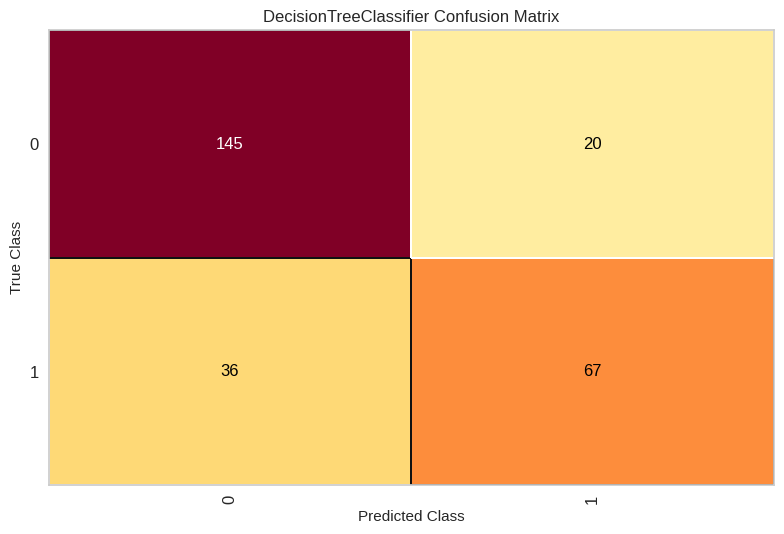

<Axes: title={'center': 'DecisionTreeClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [10]:
from yellowbrick.classifier import ConfusionMatrix

cm = ConfusionMatrix(model)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)
cm.show()

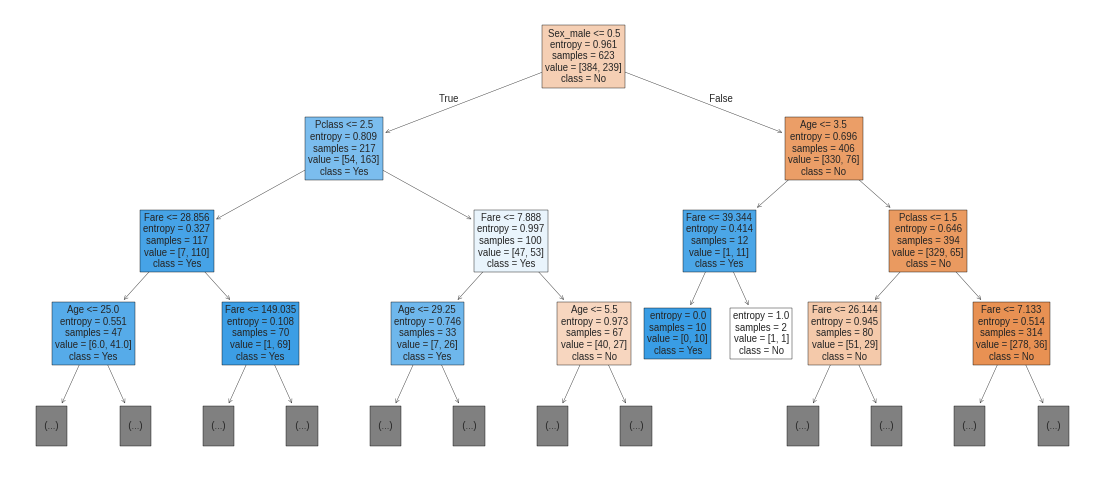

In [11]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plot_tree(
model,
feature_names=X.columns,
class_names=["No", "Yes"],
filled=True,
max_depth=3
)
plt.show()

Question_1_The first attribute in my decision tree is Sex_male. I think it appears first because a passenger’s sex had a strong connection with survival. Female passengers were more likely to survive because women and children were often given priority when entering the lifeboats.


Question_2_I think desison tree showed a better performance. The majority classifier always predicts the most common result, but the decision tree uses passenger information to make its predictions.

Question_3_This experiment shows how a model can learn from past examples. It looks at passenger details and whether each passenger survived. From this information, the model finds patterns and uses them to predict whether other passengers survived.

Question_4_min_samples_leaf=2 means that each final group in the tree must have at least two passengers. This keeps the tree from making a rule based on only one person. It also keeps the tree simpler and lowers the chance of overfitting.